Dataset loaded successfully!
Shape: (50, 7)
Columns:
['StudentID', 'CGPA', 'Internships', 'Projects', 'AptitudeTestScore', 'CommunicationSkill', 'Placed']

       DECISION TREE RESULT
Accuracy: 0.8
Accuracy (%): 80.0

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



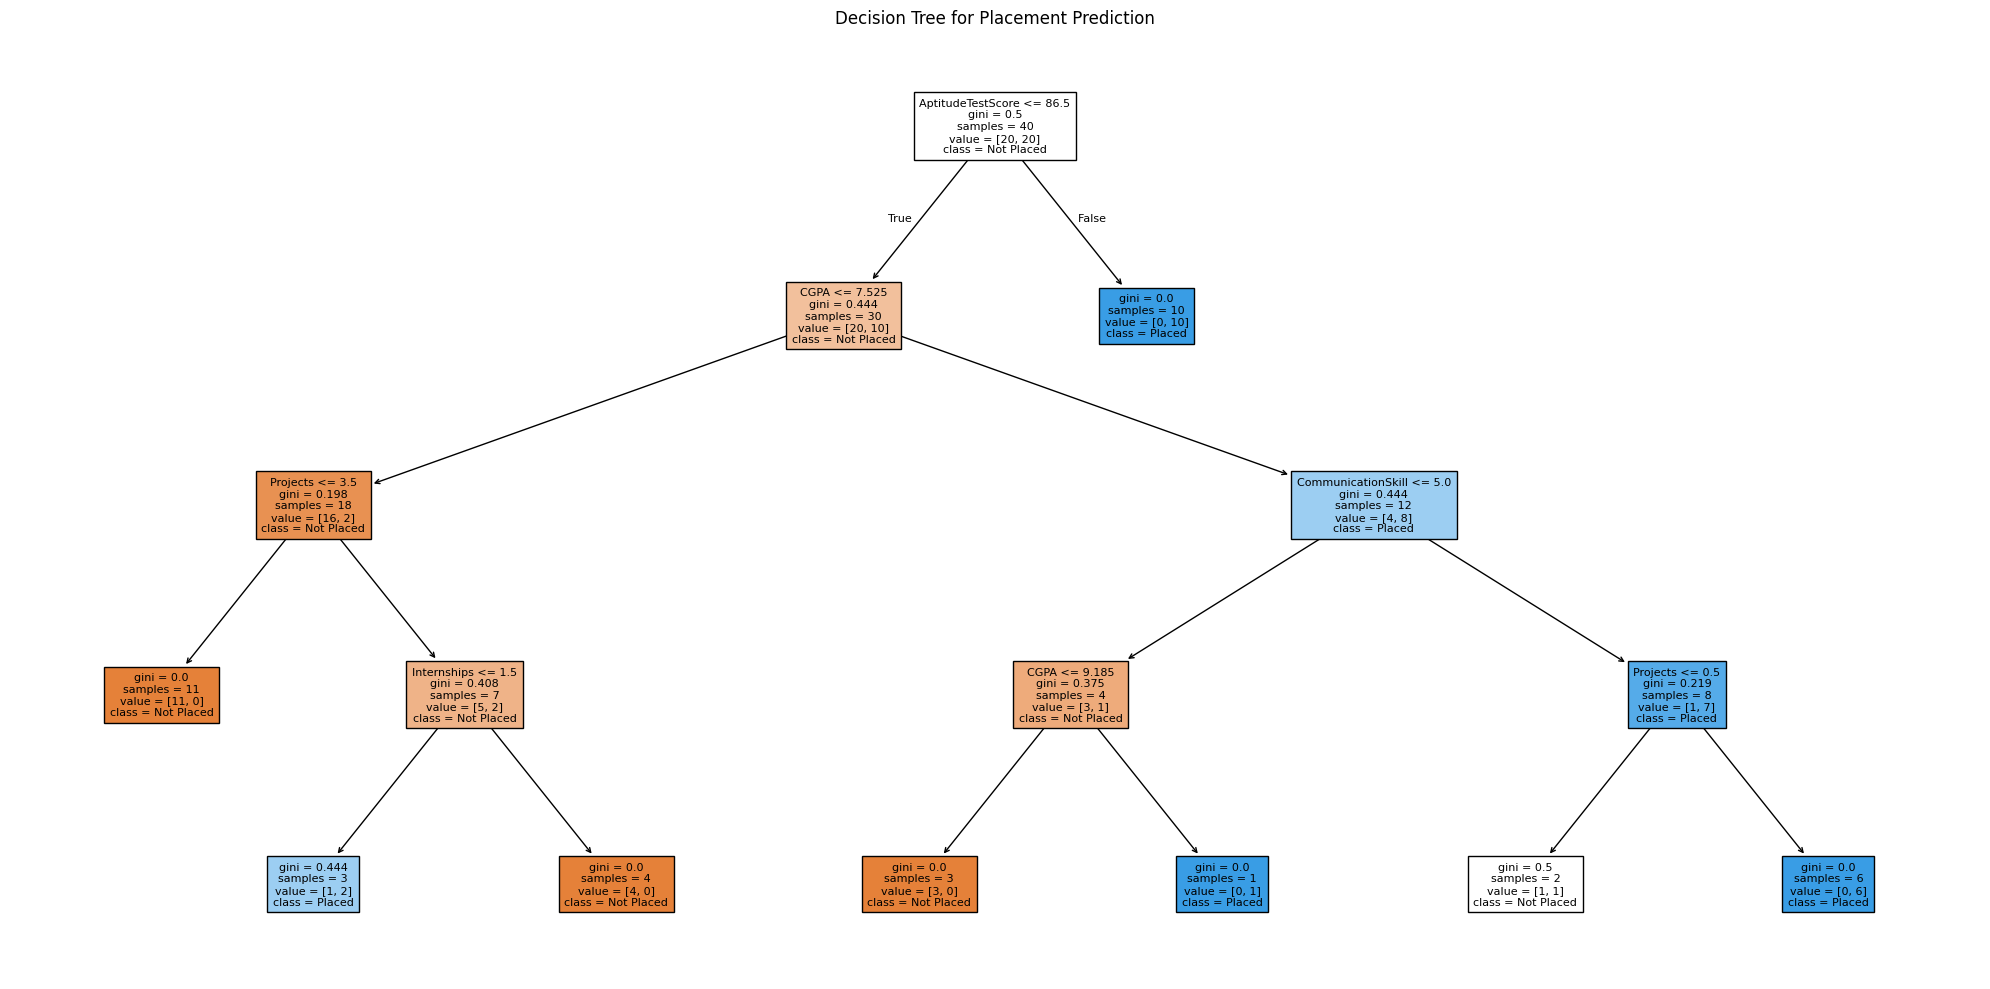


Decision tree image saved as decision_tree.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


# 1. Load dataset
df = pd.read_csv("simple_placement_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# 2. Remove IsAnomaly column if it exists
if "IsAnomaly" in df.columns:
    df = df.drop(columns=["IsAnomaly"])


# 3. Handle missing values
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()

        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value[0])


# 4. Separate input features and target

X = df.drop(columns=["Placed"])
y = df["Placed"]


# 5. Remove StudentID because it is only an ID
X = X.drop(columns=["StudentID"])


# 6. Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# 7. Create Decision Tree model

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# 8. Train the model

model.fit(X_train, y_train)


# 9. Predict test data

y_pred = model.predict(X_test)


# 10. Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("       DECISION TREE RESULT")
print("================================")

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


# 11. Classification report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 12. Plot Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree for Placement Prediction")

plt.tight_layout()


# 13. Save tree image

plt.savefig(
    "decision_tree.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nDecision tree image saved as decision_tree.png")